In [2]:
# dataset/LA_train/LA_train.zip
!cp /content/drive/MyDrive/dataset/LA_train/LA_train.zip /content/
!unzip -q /content/LA_train.zip -d /content/LA_train_data/


In [3]:
PROTOCOL_PATH = "/content/LA_train_data/LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.dev.trl.txt"
AUDIO_DIR = "/content/LA_train_data/LA/ASVspoof2019_LA_dev/flac/"

In [4]:
# Clone repository AASIST chính thức của Naver/Clova
!git clone https://github.com/clovaai/aasist.git

# Cài đặt các thư viện cần thiết (nếu Colab chưa có sẵn bản mới nhất)
!pip install torchaudio soundfile pyyaml

# Tải pre-trained weights của AASIST (mô hình base)
# 1. Xóa file trọng số bị lỗi hiện tại
# !rm AASIST.pth

# 2. Tải lại file trọng số chính thức từ GitHub (dùng Raw URL)
!wget -O AASIST.pth https://raw.githubusercontent.com/clovaai/aasist/main/models/weights/AASIST.pth

Cloning into 'aasist'...
remote: Enumerating objects: 38, done.
remote: Counting objects: 100% (28/28), done.
remote: Compressing objects: 100% (22/22), done.
remote: Total 38 (delta 12), reused 6 (delta 6), pack-reused 10 (from 1)
Receiving objects: 100% (38/38), 1.43 MiB | 47.12 MiB/s, done.
Resolving deltas: 100% (12/12), done.
--2026-03-05 16:35:23--  https://raw.githubusercontent.com/clovaai/aasist/main/models/weights/AASIST.pth
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1281532 (1.2M) [application/octet-stream]
Saving to: ‘AASIST.pth’

AASIST.pth          100%[===================>]   1.22M  --.-KB/s    in 0.008s  

2026-03-05 16:35:24 (150 MB/s) - ‘AASIST.pth’ saved [1281532/1281532]



In [5]:
# khởi tạo mô hình

import sys
import torch
import yaml

# Thêm đường dẫn repo vào sys.path để import các module của AASIST
sys.path.append('./aasist')

# Import model và tiện ích từ repo clovaai/aasist
from models.AASIST import Model

def load_aasist_model(config_path, weight_path, device):
    """Đọc cấu hình, khởi tạo mô hình và nạp trọng số."""

    # 1. Đọc file cấu hình kiến trúc mạng
    with open(config_path, 'r') as f:
        config = yaml.safe_load(f)

    # 2. Khởi tạo mô hình AASIST với tham số từ config
    model = Model(config['model_config'])

    # 3. Nạp trọng số (weights)
    # Ánh xạ trọng số lên CPU trước để tránh lỗi OOM GPU khi load, sau đó mới đẩy sang GPU
    model.load_state_dict(torch.load(weight_path, map_location='cpu'))

    # 4. Đẩy mô hình lên GPU (A100) và đặt ở chế độ Evaluation
    model = model.to(device)
    model.eval()

    return model

# Khởi tạo thiết bị
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Đường dẫn đến file config trong repo vừa clone và file weights vừa tải
config_file = "./aasist/config/AASIST.conf" # Đường dẫn có thể thay đổi tùy cấu trúc repo
weight_file = "./AASIST.pth"

# Load mô hình
aasist_model = load_aasist_model(config_file, weight_file, device)
print("Đã tải mô hình AASIST thành công!")

Đã tải mô hình AASIST thành công!


In [6]:
import os
import torchaudio
from torch.utils.data import Dataset, DataLoader

class ASVspoof2019Dataset(Dataset):
    def __init__(self, protocol_file, audio_dir, max_len=64600):
        """
        protocol_file: Đường dẫn đến file txt chứa nhãn (VD: ASVspoof2019.LA.cm.dev.trl.txt)
        audio_dir: Đường dẫn đến thư mục chứa các file .flac
        max_len: Số lượng điểm lấy mẫu cố định (AASIST thường dùng 64600 cho 4s âm thanh)
        """
        self.audio_dir = audio_dir
        self.max_len = max_len
        self.data_list = []

        # Đọc file protocol
        with open(protocol_file, 'r') as f:
            lines = f.readlines()
            for line in lines:
                parts = line.strip().split()
                if len(parts) >= 5:
                    audio_id = parts[1]
                    label_str = parts[4]

                    # Quy ước nhãn: 1 cho bonafide (thật), 0 cho spoof (giả)
                    label = 1 if label_str == "bonafide" else 0

                    self.data_list.append({
                        "audio_id": audio_id,
                        "label": label
                    })

    def __len__(self):
        return len(self.data_list)

    def __getitem__(self, idx):
        item = self.data_list[idx]
        audio_path = os.path.join(self.audio_dir, f"{item['audio_id']}.flac")

        # Load audio bằng torchaudio
        # waveform có shape: (channels, num_samples). ASVspoof là mono nên channels=1
        waveform, sample_rate = torchaudio.load(audio_path)
        waveform = waveform.squeeze(0) # Chuyển từ (1, N) thành (N)

        # Cắt hoặc đệm (Padding) để audio có độ dài chuẩn max_len
        audio_len = waveform.shape[0]
        if audio_len > self.max_len:
            # Cắt bớt phần thừa (có thể random crop hoặc lấy phần đầu, ở đây lấy phần đầu)
            waveform = waveform[:self.max_len]
        elif audio_len < self.max_len:
            # Đệm zero padding nếu âm thanh quá ngắn
            padding = self.max_len - audio_len
            waveform = torch.nn.functional.pad(waveform, (0, padding), "constant", 0)

        label = torch.tensor(item['label'], dtype=torch.long)

        return waveform, label

# --- Thiết lập DataLoader ---

# Khởi tạo Dataset
eval_dataset = ASVspoof2019Dataset(
    protocol_file=PROTOCOL_PATH,
    audio_dir=AUDIO_DIR,
    max_len=64600
)

# Khởi tạo DataLoader
# Vì dùng A100, bạn có thể thiết lập batch_size lớn (VD: 32, 64) để tăng tốc
eval_dataloader = DataLoader(
    eval_dataset,
    batch_size=32,
    shuffle=True,      # Shuffle để tạo nhiễu ngẫu nhiên trong các batch
    num_workers=4,     # Sử dụng đa luồng để load data từ Drive nhanh hơn
    pin_memory=True    # Giúp transfer data từ CPU sang GPU nhanh hơn
)

print(f"Tổng số mẫu dữ liệu: {len(eval_dataset)}")
print(f"Tổng số batch: {len(eval_dataloader)}")

Tổng số mẫu dữ liệu: 24844
Tổng số batch: 777


In [7]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve
from scipy.optimize import brentq
from scipy.interpolate import interp1d
from tqdm import tqdm # Để hiển thị thanh tiến trình

In [8]:
def calculate_eer(y_true, y_score):
    """
    Tính toán Equal Error Rate (EER).
    y_true: Nhãn thực tế (1: Bonafide/Thật, 0: Spoof/Giả)
    y_score: Điểm số dự đoán của mô hình (Logit hoặc xác suất của lớp Bonafide)
    """
    fpr, tpr, thresholds = roc_curve(y_true, y_score, pos_label=1)

    # EER là điểm giao nhau giữa đường FAR (FPR) và đường FRR (1 - TPR)
    eer = brentq(lambda x: 1. - x - interp1d(fpr, tpr)(x), 0., 1.)
    thresh = interp1d(fpr, thresholds)(eer)

    return eer, thresh, fpr, tpr

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F

def fgsm_attack(audio, epsilon, data_grad):
    # 1. Lấy dấu của gradient từ dữ liệu đầu vào
    sign_data_grad = data_grad.sign()

    # 2. Tạo âm thanh đối nghịch bằng cách cộng nhiễu
    perturbed_audio = audio + epsilon * sign_data_grad

    # 3. Giới hạn giá trị của dạng sóng âm thanh (Thường amplitude nằm trong khoảng [-1, 1])
    # Bước này quan trọng để đảm bảo âm thanh vẫn hợp lệ và có thể nghe được
    perturbed_audio = torch.clamp(perturbed_audio, -1.0, 1.0)

    return perturbed_audio

def generate_adversarial_batch(model, audio_batch, labels, epsilon, device):
    """
    Hàm này nhận một batch âm thanh, đưa qua mô hình AASIST và trả về batch âm thanh đối nghịch.
    """
    # Đảm bảo mô hình ở chế độ đánh giá, không phải training
    model.eval()

    # Đưa dữ liệu lên GPU A100
    audio_batch, labels = audio_batch.to(device), labels.to(device)

    # QUAN TRỌNG: Đặt requires_grad = True để PyTorch theo dõi tính toán gradient cho tensor đầu vào
    audio_batch.requires_grad = True

    # Truyền xuôi (Forward pass) qua mô hình AASIST
    # Lưu ý: Cấu trúc output phụ thuộc vào repo AASIST cụ thể bạn đang dùng (có thể trả về logits và hidden states)
    outputs = model(audio_batch)

    # Trong AASIST, outputs thường chứa (emb, outputs)
    if isinstance(outputs, tuple):
        logits = outputs[1]
    else:
        logits = outputs

    # Tính hàm mất mát (thường dùng Cross Entropy cho ASVspoof)
    criterion = nn.CrossEntropyLoss()
    loss = criterion(logits, labels)

    # Xóa toàn bộ gradient cũ của mô hình (để tránh cộng dồn)
    model.zero_grad()

    # Truyền ngược (Backward pass) để tính gradient của loss theo ĐẦU VÀO (audio_batch)
    loss.backward()

    # Trích xuất gradient của đầu vào
    data_grad = audio_batch.grad.data

    # Áp dụng hàm FGSM để tạo batch âm thanh đối nghịch
    perturbed_audio_batch = fgsm_attack(audio_batch, epsilon, data_grad)

    return perturbed_audio_batch

In [10]:
def evaluate_and_attack(model, dataloader, device, epsilon=0.01):
    model.eval()

    clean_scores_list = []
    adv_scores_list = []
    labels_list = []

    # Sử dụng tqdm để theo dõi tiến trình
    print(f"Bắt đầu đánh giá với Epsilon = {epsilon}")
    for batch_idx, (audio_batch, labels) in enumerate(tqdm(dataloader, desc="Processing Batches")):

        audio_batch = audio_batch.to(device)
        labels = labels.to(device)

        # ---------------------------------------------------------
        # BƯỚC 1: Lấy điểm số trên dữ liệu SẠCH (Clean)
        # ---------------------------------------------------------
        with torch.no_grad(): # Không cần tính gradient cho bước inference sạch
            outputs_clean = model(audio_batch)
            logits_clean = outputs_clean[1] if isinstance(outputs_clean, tuple) else outputs_clean

            # Lấy logit của class 1 (Bonafide) làm score
            scores_clean = logits_clean[:, 1].cpu().numpy()
            clean_scores_list.extend(scores_clean)

        # ---------------------------------------------------------
        # BƯỚC 2: Tạo dữ liệu ĐỐI NGHỊCH (Adversarial) bằng FGSM
        # ---------------------------------------------------------
        # Gọi hàm generate_adversarial_batch mà chúng ta đã viết ở bước trước
        # Chú ý: Hàm này CẦN tính gradient nên không dùng torch.no_grad()
        adv_audio_batch = generate_adversarial_batch(model, audio_batch, labels, epsilon, device)

        # ---------------------------------------------------------
        # BƯỚC 3: Lấy điểm số trên dữ liệu ĐỐI NGHỊCH
        # ---------------------------------------------------------
        with torch.no_grad(): # Tương tự, inference không cần gradient
            outputs_adv = model(adv_audio_batch)
            logits_adv = outputs_adv[1] if isinstance(outputs_adv, tuple) else outputs_adv

            scores_adv = logits_adv[:, 1].cpu().numpy()
            adv_scores_list.extend(scores_adv)

        labels_list.extend(labels.cpu().numpy())

        # (Tùy chọn) Break sớm để test code chạy đúng không trước khi chạy hết dataset
        # if batch_idx == 10: break

    return np.array(labels_list), np.array(clean_scores_list), np.array(adv_scores_list)

# Thực thi hàm
epsilon_value = 0.005 # Bạn có thể tinh chỉnh: 0.001, 0.005, 0.01...
true_labels, clean_scores, adv_scores = evaluate_and_attack(
    aasist_model,
    eval_dataloader,
    device,
    epsilon=epsilon_value
)

Bắt đầu đánh giá với Epsilon = 0.005


Processing Batches: 100%|██████████| 777/777 [06:07<00:00,  2.11it/s]


<>:22: SyntaxWarning: invalid escape sequence '\e'
<>:22: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_896/3394651050.py:22: SyntaxWarning: invalid escape sequence '\e'
  label=f'FGSM Attack $\epsilon$={epsilon_value} (EER = {adv_eer*100:.2f}%)')


Kết quả Đánh giá AASIST (ASVspoof 2019 LA)
EER Dữ liệu sạch (Clean)      : 2.24%
EER Dữ liệu tấn công (FGSM)   : 58.33%


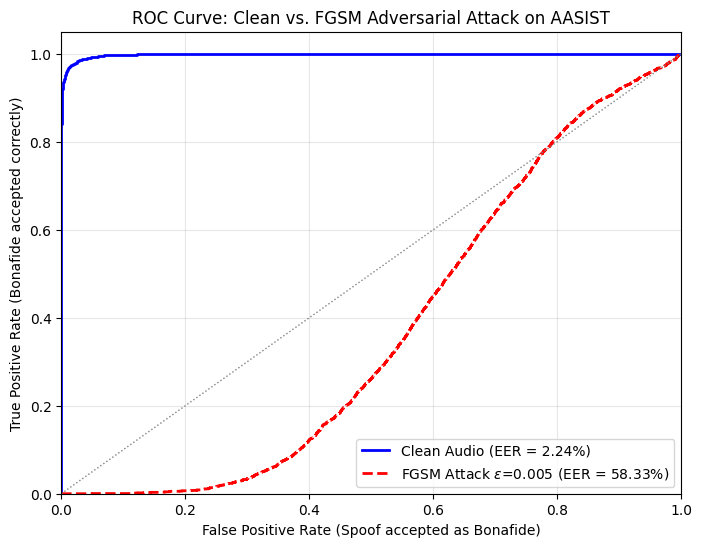

In [11]:
# Tính toán EER
clean_eer, clean_thresh, clean_fpr, clean_tpr = calculate_eer(true_labels, clean_scores)
adv_eer, adv_thresh, adv_fpr, adv_tpr = calculate_eer(true_labels, adv_scores)

print("="*40)
print(f"Kết quả Đánh giá AASIST (ASVspoof 2019 LA)")
print(f"EER Dữ liệu sạch (Clean)      : {clean_eer * 100:.2f}%")
print(f"EER Dữ liệu tấn công (FGSM)   : {adv_eer * 100:.2f}%")
print("="*40)

# ---------------------------------------------------------
# Vẽ biểu đồ ROC Curve
# ---------------------------------------------------------
plt.figure(figsize=(8, 6))

# Plot Clean ROC
plt.plot(clean_fpr, clean_tpr, color='blue', lw=2,
         label=f'Clean Audio (EER = {clean_eer*100:.2f}%)')

# Plot Adversarial ROC
plt.plot(adv_fpr, adv_tpr, color='red', lw=2, linestyle='--',
         label=f'FGSM Attack $\epsilon$={epsilon_value} (EER = {adv_eer*100:.2f}%)')

# Đường ngẫu nhiên (Random guess)
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle=':')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Spoof accepted as Bonafide)')
plt.ylabel('True Positive Rate (Bonafide accepted correctly)')
plt.title('ROC Curve: Clean vs. FGSM Adversarial Attack on AASIST')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

# Lưu ảnh chất lượng cao trên Colab
plt.savefig('roc_curve_aasist_fgsm.png', dpi=300, bbox_inches='tight')
plt.show()